# **Credit Card Fraud Detection**
### **Binary Classification on Highly Imbalanced Data**

## **Project Overview**
This project builds a fraud detection system on the Kaggle Credit Card Fraud dataset 284,807 transactions of which only 492 (0.17%) are fraudulent.

**The core challenge:** Extreme class imbalance means naive models achieve
99.83% accuracy by predicting "legitimate" for everything — while catching
zero fraud. This project addresses that challenge directly.

## **Approach**
- **EDA:** Identified high-signal features through correlation analysis and visual distribution comparison
- **Preprocessing:** Stratified train/test split, StandardScaler on Amount and Time, SMOTE for synthetic oversampling
- **Modelling:** Compared 6 models across 3 algorithms × 2 imbalance strategies (SMOTE vs class weights)
- **Evaluation:** F1 Score and AUC-ROC as primary metrics, with detailed confusion matrix analysis
- **Explainability:** SHAP values to explain global feature importance and individual predictions

## **Best Result**
**XGBoost with class weights**
- F1 Score: 0.8586 | AUC-ROC: 0.9682
- Caught 82 out of 98 fraud cases in the test set
- Only 11 legitimate transactions wrongly flagged

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
df = pd.read_csv(path + "/creditcard.csv")
pd.set_option('display.max_columns', None)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [ ]:
df.isnull().sum()


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


- The dataset contains 284,807 rows and 31 columns
- There are no missing (null) values
- The dataset consists of only two data types: Float & Integer
- Time and Amount are in their original scale, these features have not been standardized or normalized


### **Class Distribution**

In [ ]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct.round(2))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.83
1     0.17
Name: proportion, dtype: float64


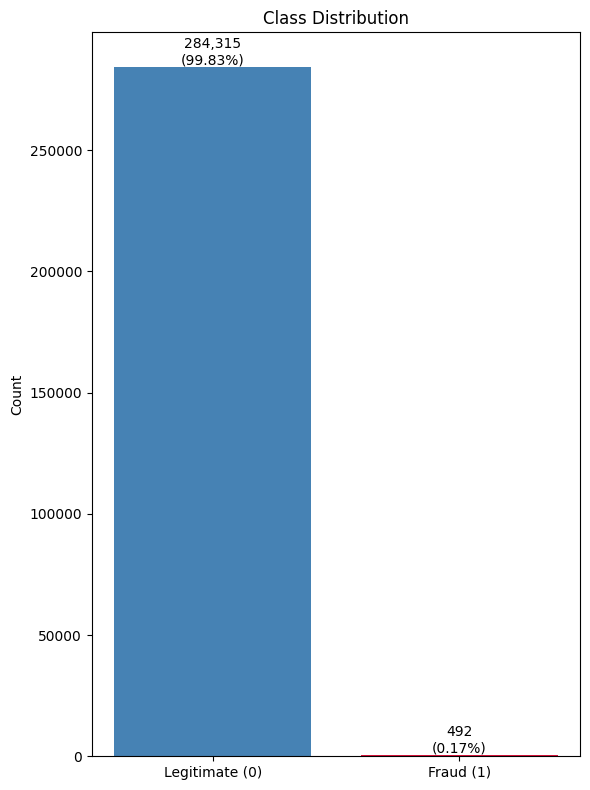

In [ ]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values, color=['steelblue', 'crimson'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 1000, f'{v:,}\n({class_pct.values[i]:.2f}%)', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
baseline_accuracy = class_pct.values[0]
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")

Baseline Accuracy: 99.83%


If a model predicts "legitimate" for every transaction, it achieves 99.83% accuracy — yet catches zero fraud. This is why accuracy is useless here and why F1 Score and AUC-ROC are used instead.

### **Feature Distributions (Fraud vs Legitimate)**

In [ ]:
correlations = df.corr()['Class'].drop("Class")

In [ ]:
correlations_sorted = correlations.abs().sort_values(ascending=False)
print(correlations_sorted)

V17       0.326481
V14       0.302544
V12       0.260593
V10       0.216883
V16       0.196539
V3        0.192961
V7        0.187257
V11       0.154876
V4        0.133447
V18       0.111485
V1        0.101347
V9        0.097733
V5        0.094974
V2        0.091289
V6        0.043643
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
Time      0.012323
V28       0.009536
V24       0.007221
Amount    0.005632
V13       0.004570
V26       0.004455
V15       0.004223
V25       0.003308
V23       0.002685
V22       0.000805
Name: Class, dtype: float64


- Features such as V17, V14, V12, and V10 show relatively strong correlations with fraud, indicating clear differences between fraudulent and legitimate transactions
- Many features (e.g., V22, V23, V25) have near-zero correlation, suggesting little to no linear relationship with fraud
- Amount has a very low correlation (~0.006), indicating transaction size alone does not strongly distinguish fraud cases
- Overall, only a small subset of features provides strong linear signals for fraud detection, while the majority contribute weak or minimal information

### **Feature Distribution: Fraud vs Legitimate**

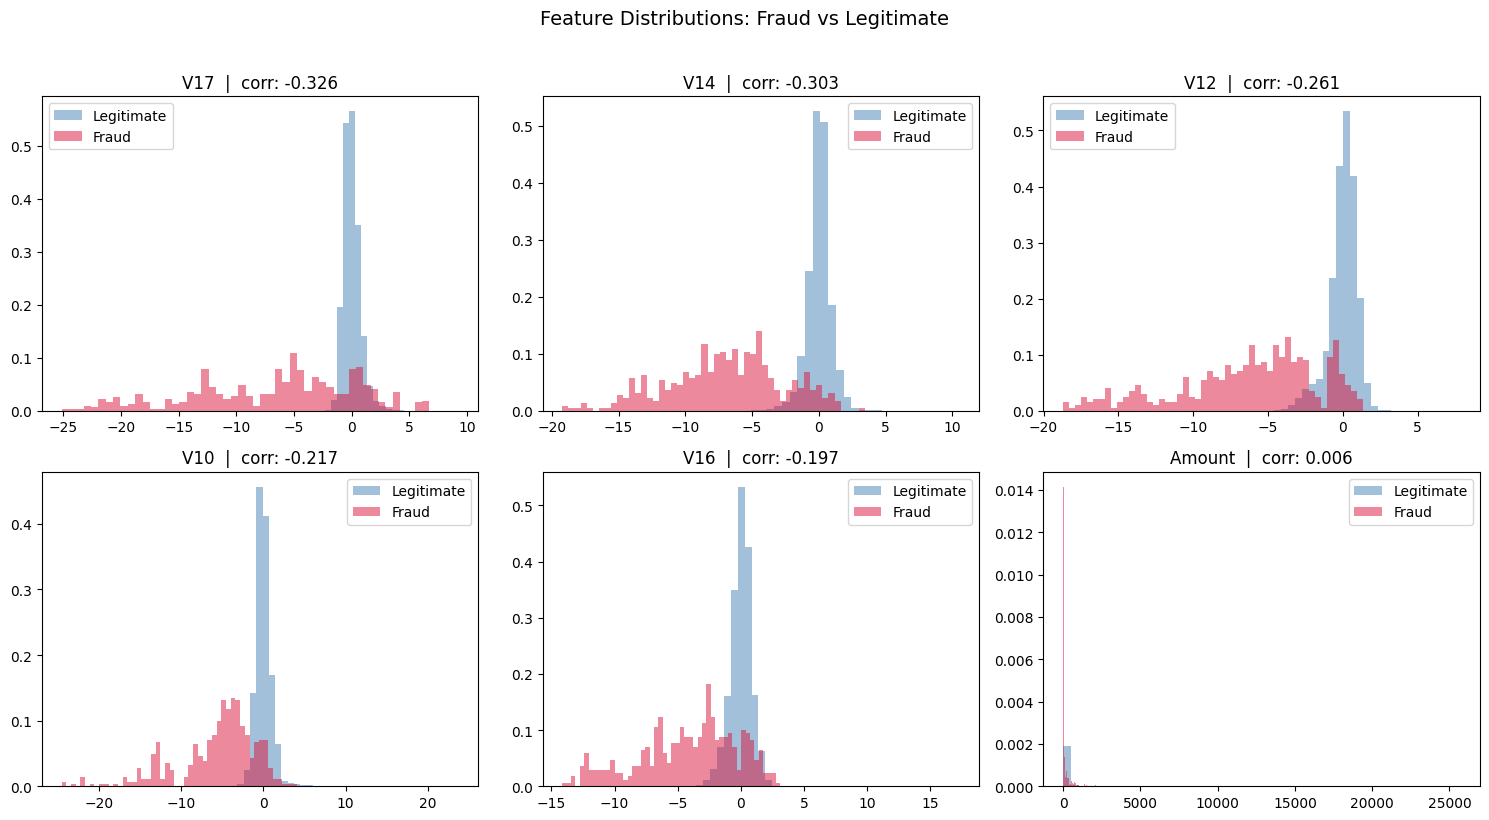

In [ ]:
features_to_plot = ['V17', 'V14', 'V12', 'V10', 'V16', 'Amount']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    axes[i].hist(df[df['Class'] == 0][feature], bins=50, alpha=0.5, label='Legitimate', color='steelblue', density=True)
    axes[i].hist(df[df['Class'] == 1][feature], bins=50, alpha=0.5, label='Fraud', color='crimson', density=True)
    axes[i].set_title(f'{feature}  |  corr: {correlations[feature]:.3f}')
    axes[i].legend()

plt.suptitle('Feature Distributions: Fraud vs Legitimate', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### **Feature Distribution Insights (Fraud vs Legitimate)**

**Strong separation (high predictive potential)**
- **V17, V14, V12**
  - Clear distinction between fraud and legitimate distributions
  - Fraud transactions are strongly **skewed toward negative values**
  - Likely to be among the most important features for modeling

**Moderate separation**
- **V10, V16**
  - Similar negative skew pattern for fraud
  - More overlap with legitimate class → weaker discrimination than above

**Weak / no separation**
- **Amount**
  - Distributions for fraud and legitimate transactions largely overlap
  - Correlation near zero → low predictive value on its own
  - Contrary to intuition, transaction amount has virtually no correlation with fraud (0.006)
  - Fraudulent transactions mirror the amount distribution of legitimate ones, suggesting fraudsters deliberately avoid suspicious amounts

### **Amount and Time Analysis**

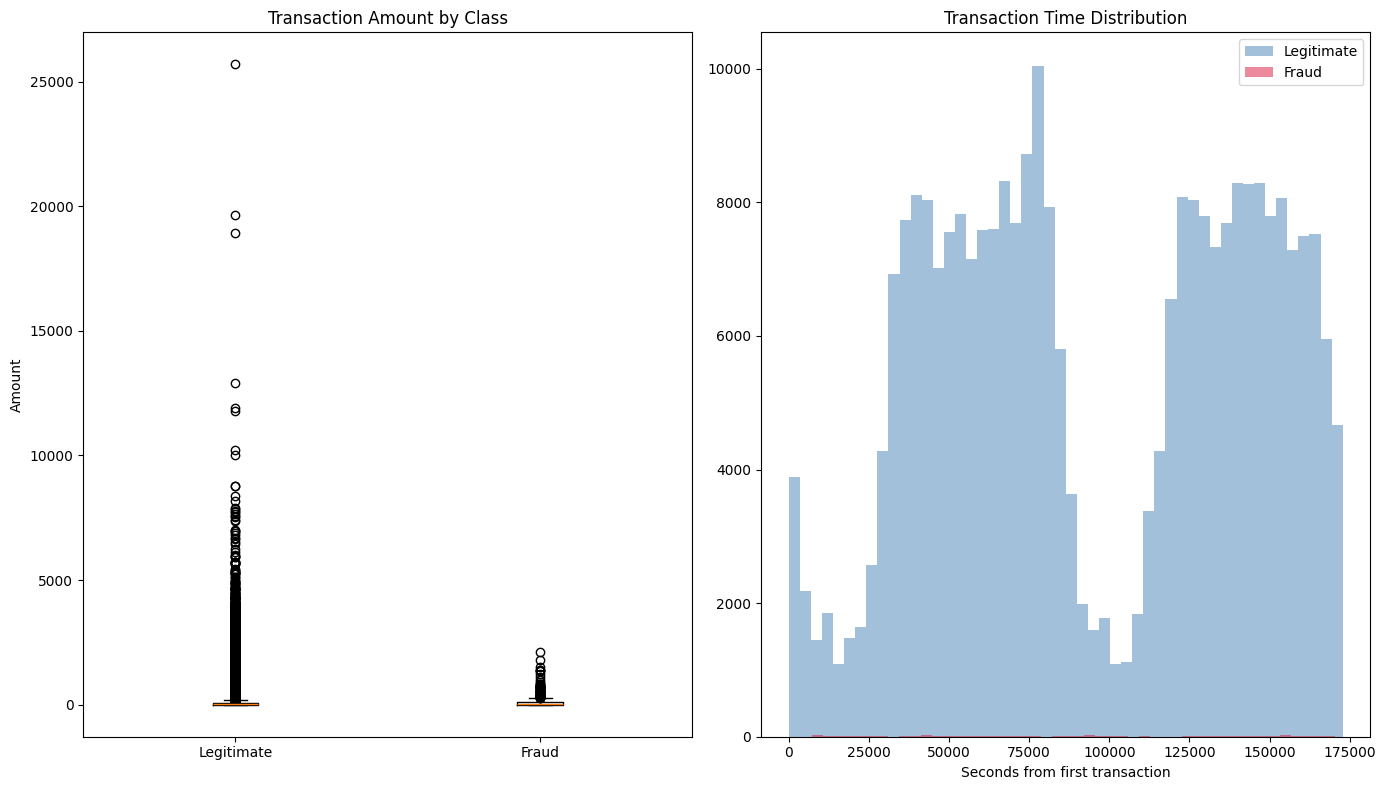

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].boxplot([df[df['Class']==0]['Amount'], df[df['Class']==1]['Amount']], tick_labels=['Legitimate', 'Fraud'])
axes[0].set_title('Transaction Amount by Class')
axes[0].set_ylabel('Amount')

axes[1].hist(df[df['Class']==0]['Time'], bins=50, alpha=0.5, label='Legitimate', color='steelblue')
axes[1].hist(df[df['Class']==1]['Time'], bins=50, alpha=0.5, label='Fraud', color='crimson')
axes[1].set_title('Transaction Time Distribution')
axes[1].set_xlabel('Seconds from first transaction')
axes[1].legend()

plt.tight_layout()
plt.show()

Fraudsters don't make huge transactions. They keep amounts relatively modest probably deliberately, to avoid triggering alerts. The maximum fraud amount is far lower than the maximum legitimate amount.

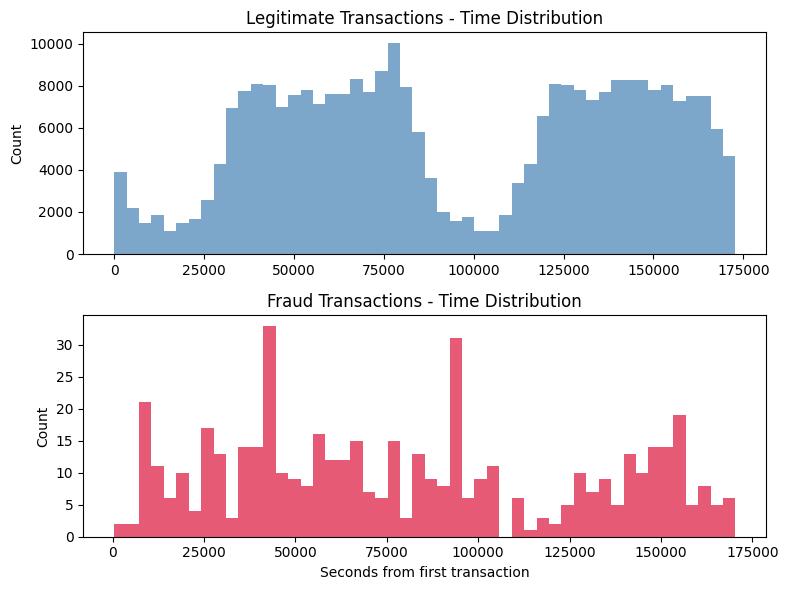

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].hist(df[df['Class'] == 0]['Time'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Legitimate Transactions - Time Distribution')
axes[0].set_ylabel('Count')

axes[1].hist(df[df['Class'] == 1]['Time'], bins=50, color='crimson', alpha=0.7)
axes[1].set_title('Fraud Transactions - Time Distribution')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Seconds from first transaction')

plt.tight_layout()
plt.show()

Fraudulent transactions show higher relative activity during nighttime hours when legitimate spending drops. This suggests fraud is not constrained by the cardholder's natural spending rhythm.

In [ ]:
fraud_time = df[df['Class'] == 1]['Time']
legit_time = df[df['Class'] == 0]['Time']

print("Fraud - mean time:", fraud_time.mean())
print("Legit - mean time:", legit_time.mean())

Fraud - mean time: 80746.80691056911
Legit - mean time: 94838.20225805884


- Legitimate transactions have extreme outliers up to 25k. Fraud maxes out around 2,500  fraudsters keep amounts moderate.
- Legitimate volume follows a clear day/night rhythm with two visible dips. Fraud appears more uniform across time  it doesn't follow normal human spending patterns.
- Neither Amount nor Time alone is a strong fraud predictor, but they carry subtle signals the model may still use

### **Preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

### **Feature / Target Split**
Separate the dataset into input features and the fraud label.

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

### **Train-Test Split**
Use stratification to preserve the rare fraud class distribution.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [ ]:
print(f"Train fraud = {y_train.mean() * 100:.2f}%")
print(f"Test fraud = {y_test.mean() * 100:.2f}%")

Train fraud = 0.17%
Test fraud = 0.17%


Verified: both splits preserve the original 0.17% fraud ratio, ensuring the test set is a realistic sample of real-world conditions."

### **Scaling**
Standardize `Time` and `Amount` so scale-sensitive models behave correctly.

In [ ]:
scaler = StandardScaler()

X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

### **SMOTE (Training Only)**
Apply oversampling only to the training set to avoid data leakage.

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_smote).value_counts().to_dict())
print("Test set class distribution:", y_test.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}
Test set class distribution: {0: 56864, 1: 98}


Before SMOTE: 227,451 legitimate vs 394 fraud (ratio ~577:1)
After SMOTE:  227,451 legitimate vs 227,451 fraud (ratio 1:1)

SMOTE generated 227,057 synthetic fraud examples by interpolating between
real fraud transactions in feature space. The test set remains untouched
with its natural imbalance (56,864 legitimate, 98 fraud) to simulate
real-world evaluation conditions.

SMOTE generates 227,057 synthetic samples from only 394 real fraud cases. This is a significant extrapolation  in the modelling phase we will also test class_weight='balanced' as an alternative that avoids synthetic data entirely

### **Modeling**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score)

In [ ]:
models = {
    'Logistic Regression (SMOTE)': LogisticRegression(max_iter=1000, random_state=42),
    'Logistic Regression (CW)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),

    'Random Forest (SMOTE)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest (CW)': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),

    'XGBoost (SMOTE)': XGBClassifier(eval_metric='logloss', random_state=42),
    'XGBoost (CW)': XGBClassifier(scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
                                   eval_metric='logloss', random_state=42),
}

In [ ]:
def train_and_evaluate(name, model, X_tr, y_tr):

    # Train
    model.fit(X_tr, y_tr)

    # Predict on the REAL test set (always the same)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                target_names=['Legitimate', 'Fraud']))
    print(f"AUC-ROC: {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {'model': name, 'f1': f1, 'auc': auc, 'fitted_model': model}


  Logistic Regression (SMOTE)
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC-ROC: 0.9699


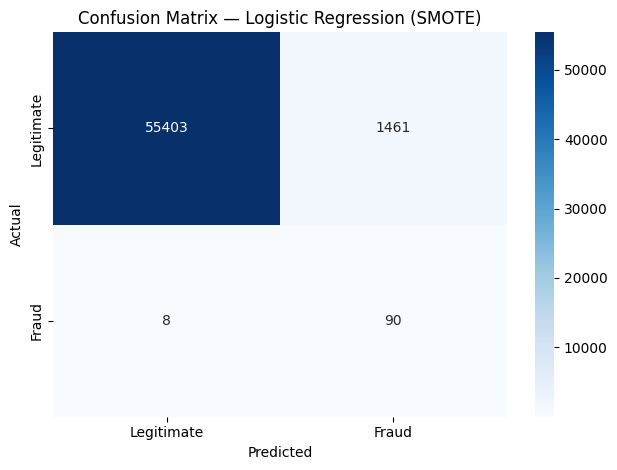


  Logistic Regression (CW)
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

AUC-ROC: 0.9722


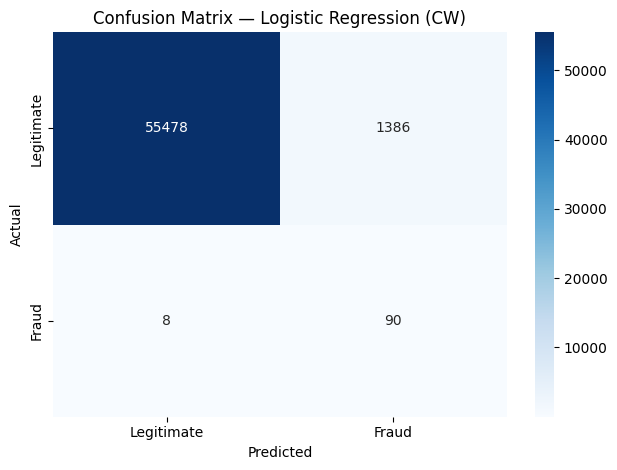


  Random Forest (SMOTE)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9731


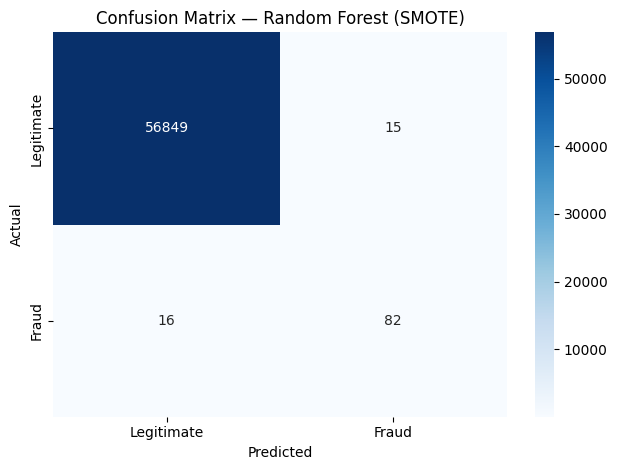


  Random Forest (CW)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9529


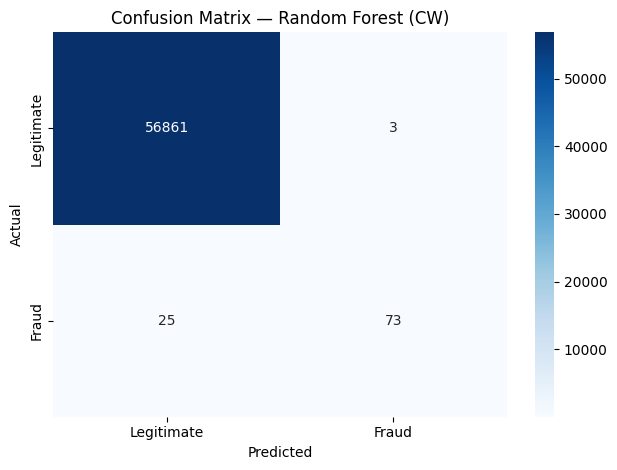


  XGBoost (SMOTE)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9792


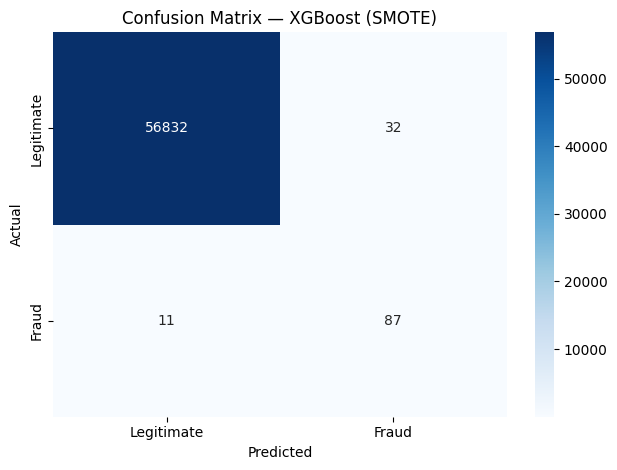


  XGBoost (CW)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9682


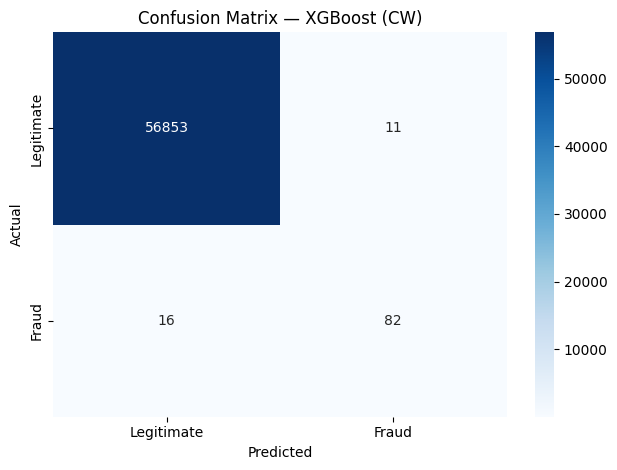

In [ ]:
results = []

for name, model in models.items():
    # SMOTE models train on balanced synthetic data
    if 'SMOTE' in name:
        result = train_and_evaluate(name, model, X_train_smote, y_train_smote)
    # Class weight models train on original imbalanced data
    else:
        result = train_and_evaluate(name, model, X_train, y_train)

    results.append(result)

In [ ]:
results_df = pd.DataFrame([{
    'Model': r['model'],
    'F1 Score': round(r['f1'], 4),
    'AUC-ROC': round(r['auc'], 4)
} for r in results])

results_df = results_df.sort_values('F1 Score', ascending=False)
print(results_df.to_string(index=False))

                      Model  F1 Score  AUC-ROC
               XGBoost (CW)    0.8586   0.9682
      Random Forest (SMOTE)    0.8410   0.9731
         Random Forest (CW)    0.8391   0.9529
            XGBoost (SMOTE)    0.8018   0.9792
   Logistic Regression (CW)    0.1144   0.9722
Logistic Regression (SMOTE)    0.1092   0.9699


### **Model Evaluation Summary**

#### **Metric Priority**
Accuracy was deliberately excluded as a metric. A model predicting
"legitimate" for every transaction achieves 99.83% accuracy yet catches zero fraud. Instead, models were evaluated on F1 Score (balance of precision and recall) and AUC-ROC (overall ranking ability), with close attention to False Negatives (missed fraud) and False Positives (innocent customers blocked).

#### **Key Findings**

The effectiveness of **SMOTE vs class weighting** varies by model.

- Logistic Regression: minimal difference between strategies  
- Random Forest: SMOTE slightly improves recall and F1  
- XGBoost: class weighting provides better overall balance  

This indicates that the optimal imbalance strategy is model-dependent rather than universal.

**Model Progression**
As expected, model complexity correlated with performance:
- Logistic Regression established the baseline but struggled with the
  non-linear patterns in the PCA features
- Random Forest improved significantly, capturing feature interactions that Logistic Regression missed
- XGBoost delivered the strongest results, benefiting from sequential
  error correction across boosting rounds

**Why Not Random Forest (CW)?**
Random Forest (CW) prioritizes precision, producing very few false positives, but at the cost of lower recall. With a fraud recall of 0.74, it misses a meaningful portion of fraudulent transactions compared to the top-performing model.

#### **Chosen Model - XGBoost (CW)**
XGBoost with class weights achieves the best balance across all metrics:
- **True Positives:** 82 out of 98 fraud cases caught (83.7% recall)
- **False Negatives:** 16 fraud cases missed
- **False Positives:** 11 innocent customers wrongly blocked
- **F1 Score:** 0.8586
- **AUC-ROC:** 0.9682

The class_weight approach outperformed SMOTE for XGBoost specifically
because XGBoost's boosting mechanism already focuses on misclassified
examples synthetic oversampling added noise without adding signal.

### **SHAP Explainability**

In [ ]:
import shap

# Extracting the fitted XGBoost (CW) model from the results list
xgb_cw_model = next(r['fitted_model'] for r in results if r['model'] == 'XGBoost (CW)')

# Creating the SHAP explainer
explainer = shap.TreeExplainer(xgb_cw_model)

# Computing SHAP values on the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)

SHAP values shape: (56962, 30)
X_test shape: (56962, 30)


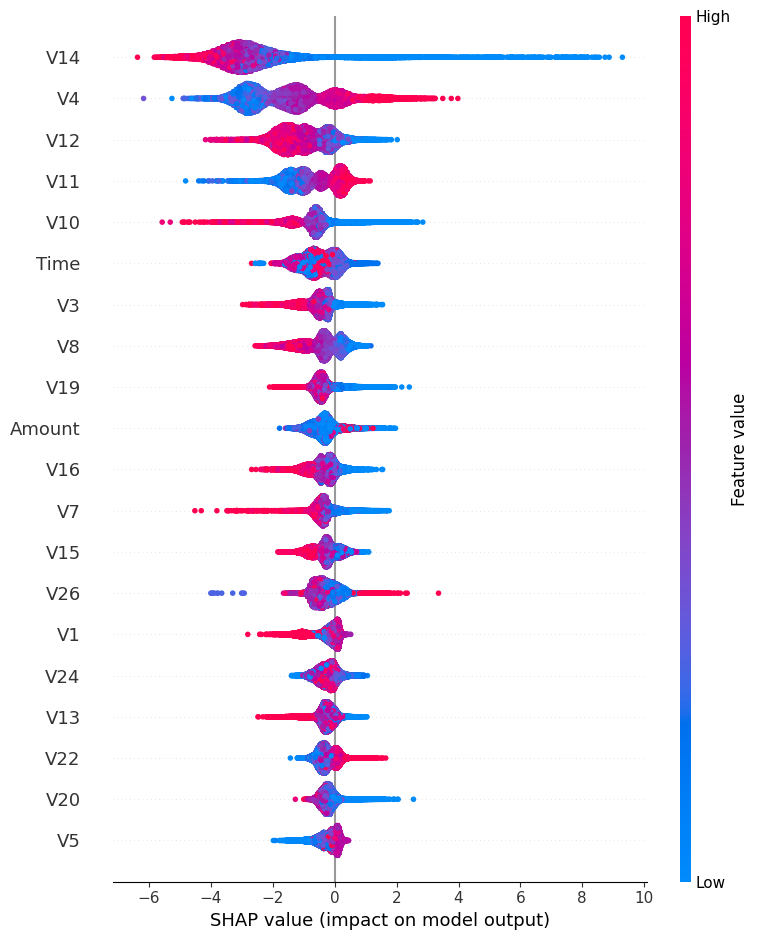

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="dot")

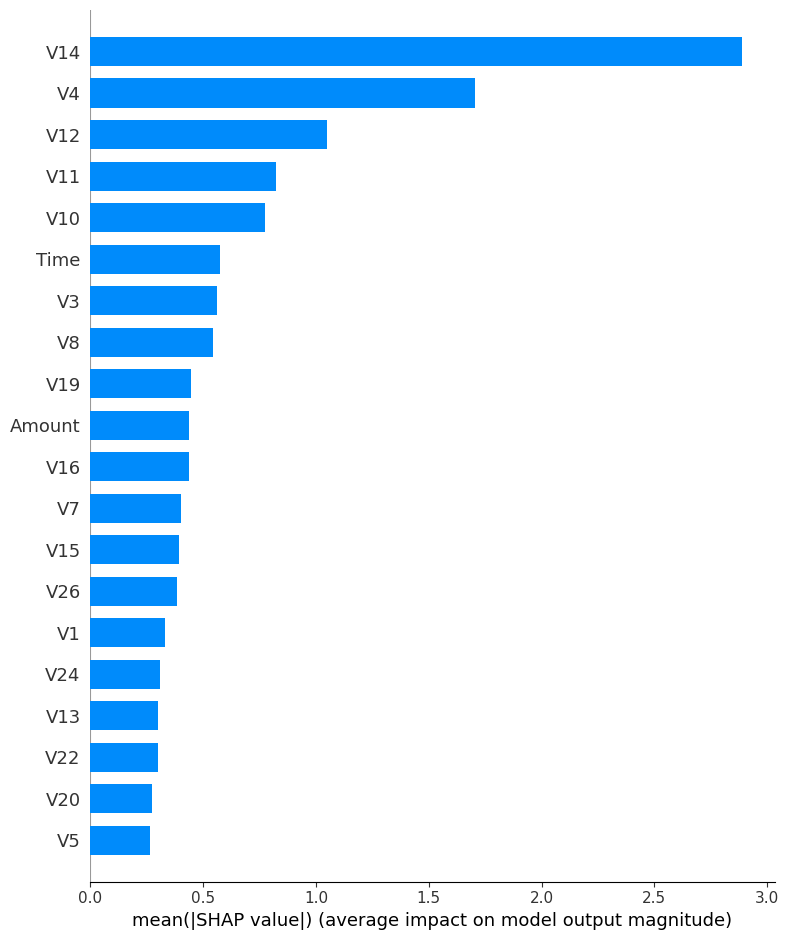

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar")

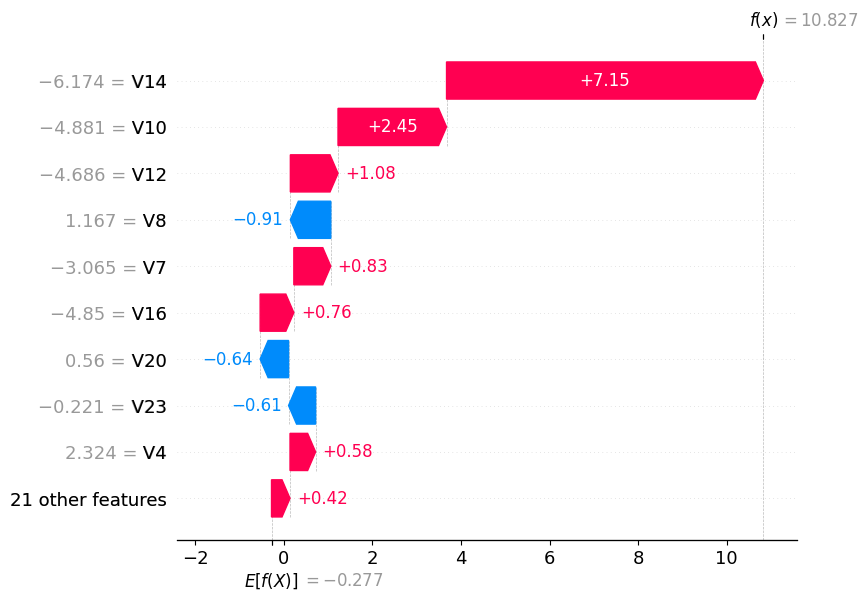

In [ ]:
# Find fraud cases in the test set
fraud_indices = X_test[y_test == 1].index
first_fraud_idx = fraud_indices[0]

# Get its position in X_test
pos = X_test.index.get_loc(first_fraud_idx)

# Create explanation object
explanation = shap.Explanation(
    values=shap_values[pos],
    base_values=explainer.expected_value,
    data=X_test.iloc[pos],
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(explanation)

### **Explainability - SHAP Analysis**

#### **Global Feature Importance**
V14 is the most influential feature in the model, followed by V17 and V12. This partially confirms EDA findings — all three were top correlators with fraud but the ranking differs. V17 had the strongest linear correlation (0.326) yet V14 dominates SHAP importance,suggesting XGBoost found richer non-linear patterns in V14 that linear correlation alone could not capture.

#### **Colour Pattern Confirms EDA**
In EDA, fraud transactions showed extreme negative values for V14, V17, and V12. The SHAP summary plot confirms this blue dots (low feature values) appear on the positive SHAP side for these features, meaning low values of V14, V17, V12 push the model strongly toward predicting fraud.The model learned exactly what the data showed.

#### **Single Transaction Explanation**
The waterfall plot for one confirmed fraud transaction shows V14 as the dominant driver its extreme negative value pushed the prediction strongly toward fraud, consistent with both the global importance ranking and EDA distributions.